In [2]:
import torch
import transformers
import datasets

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/home/kema/miniforge3/envs/mlsys/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1+cu121
transformers: 5.7.0
datasets: 4.8.5
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Qwen2Config
from datasets import load_dataset

print("Imports passed.")

Imports passed.


In [4]:
import torch
from itertools import chain
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, Qwen2Config,
    Trainer, TrainingArguments, DataCollatorForLanguageModeling,
)

# 1. Tokenizer (复用 Qwen，免去自己训词表)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")
tokenizer.pad_token = tokenizer.eos_token
EOS, VOCAB_SIZE = tokenizer.eos_token, len(tokenizer)

# 2. Tiny 模型（~40M params，从头随机初始化）
config = Qwen2Config(
    hidden_size=128, intermediate_size=512,
    num_hidden_layers=4, num_attention_heads=4,
    num_key_value_heads=2, vocab_size=VOCAB_SIZE,
    max_position_embeddings=512,
)
model = AutoModelForCausalLM.from_config(config)

# 3. 数据：load → tokenize → concat → chunk（§3.2 + §3.3）
raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
raw = raw.filter(lambda x: len(x["text"].strip()) > 0)
BLOCK = 256

def tokenize_and_chunk(examples):
    texts = [t + EOS for t in examples["text"]]
    tok = tokenizer(texts, add_special_tokens=False)
    flat = {k: list(chain(*v)) for k, v in tok.items()}
    total = (len(flat["input_ids"]) // BLOCK) * BLOCK
    return {k: [v[i:i+BLOCK] for i in range(0, total, BLOCK)]
            for k, v in flat.items()}

dataset = raw.map(tokenize_and_chunk, batched=True, remove_columns=raw.column_names)

# 4. Collator: labels = input_ids.clone()（§3.4）
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# 5. 训练（warmup + cosine，§4.2）
args = TrainingArguments(
    output_dir="./pt_out",
    learning_rate=1e-3,                  # demo 放大 10x，几百步就能看到 loss 降
    warmup_steps=15, lr_scheduler_type="cosine",
    max_steps=300, per_device_train_batch_size=8,
    logging_steps=20, save_strategy="no", report_to="none",
)
trainer = Trainer(model=model, args=args, train_dataset=dataset, data_collator=collator)
trainer.train()

Map: 100%|██████████| 23767/23767 [00:01<00:00, 18453.39 examples/s]


Step,Training Loss
20,11.266463
40,8.706420
60,7.434354
80,7.093651
100,6.827554
120,6.715212
140,6.578255
160,6.429913
180,6.447270
200,6.481757


TrainOutput(global_step=300, training_loss=7.035656458536784, metrics={'train_runtime': 15.593, 'train_samples_per_second': 153.915, 'train_steps_per_second': 19.239, 'total_flos': 75196425830400.0, 'train_loss': 7.035656458536784, 'epoch': 0.24193548387096775})

Training 7x7 MatrixNet:   0%|          | 0/20000 [00:00<?, ?it/s]/home/kema/miniforge3/envs/mlsys/lib/python3.10/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Training 7x7 MatrixNet:  10%|█         | 2017/20000 [00:39<20:32, 14.59it/s, loss=4.4511]   



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-18.014 -43.97 ]
 [ -1.702  -6.044]]
Prediction (first 2x2 corner):
 [[-17.611 -47.293]
 [ -1.     -3.935]]
Full Matrix MAE: 1.548734



Training 7x7 MatrixNet:  20%|██        | 4020/20000 [00:49<01:24, 189.48it/s, loss=3.7171]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 16.21   -5.517]
 [-11.523  40.62 ]]
Prediction (first 2x2 corner):
 [[ 17.121  -4.598]
 [-13.787  42.059]]
Full Matrix MAE: 1.430104



Training 7x7 MatrixNet:  30%|███       | 6027/20000 [01:01<01:18, 178.16it/s, loss=2.8360]

...

Training 7x7 MatrixNet:  80%|████████  | 16028/20000 [01:56<00:21, 186.37it/s, loss=0.2459]



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 17.789   9.182]
 [-41.387  -4.216]]
Prediction (first 2x2 corner):
 [[ 17.929   7.778]
 [-41.794  -4.62 ]]
Full Matrix MAE: 0.544530



Training 7x7 MatrixNet:  90%|█████████ | 18027/20000 [02:06<00:10, 184.68it/s, loss=0.1929]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 18.887 -14.181]
 [-10.064 -11.784]]
Prediction (first 2x2 corner):
 [[ 19.205 -14.121]
 [ -9.647 -12.332]]
Full Matrix MAE: 0.266187



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [02:17<00:00, 145.12it/s, loss=0.1305]


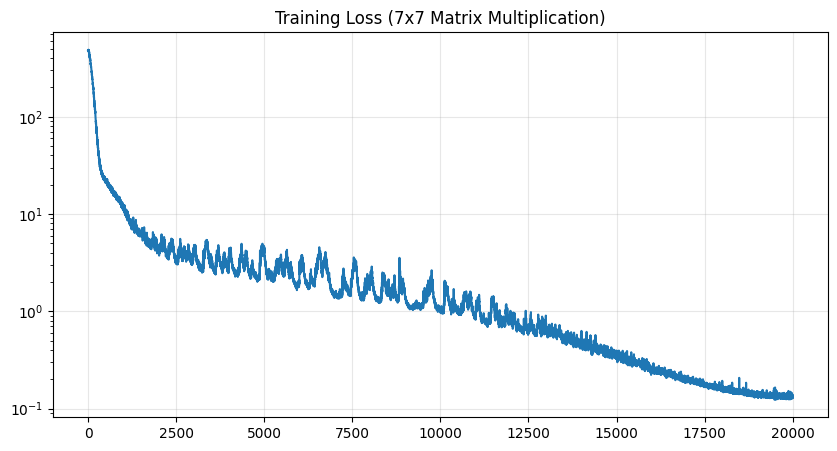

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

## Modified version to test interpolation & extrapolation

Training 7x7 MatrixNet:  10%|█         | 2035/20000 [00:11<02:49, 106.27it/s, loss=3.7439] 



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-3.105 -2.521]
 [13.237 39.263]]
Prediction (first 2x2 corner):
 [[-5.12  -3.098]
 [11.593 41.386]]
Full Matrix MAE: 1.387106



Training 7x7 MatrixNet:  20%|██        | 4024/20000 [00:21<01:21, 194.89it/s, loss=2.2858]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 29.152 -24.725]
 [  1.295 -16.747]]
Prediction (first 2x2 corner):
 [[ 27.032 -23.16 ]
 [  2.721 -18.399]]
Full Matrix MAE: 1.402807



Training 7x7 MatrixNet:  30%|███       | 6019/20000 [00:31<01:13, 190.71it/s, loss=2.2313]

...



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-14.621  18.781]
 [  2.845   6.247]]
Prediction (first 2x2 corner):
 [[-14.663  18.442]
 [  2.921   6.35 ]]
Full Matrix MAE: 0.306154



Training 7x7 MatrixNet:  90%|█████████ | 18038/20000 [01:32<00:09, 205.49it/s, loss=0.1669]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ -0.574 -35.085]
 [ -0.297  -7.677]]
Prediction (first 2x2 corner):
 [[ -0.568 -35.289]
 [ -0.42   -7.973]]
Full Matrix MAE: 0.325058



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [01:41<00:00, 196.55it/s, loss=0.1424]


{'scale': 1, 'mean_MAE': 1.1328475534915925, 'mean_relative_error': 1.6252941489219666, 'max_abs_error': 7.060744285583496}
{'scale': 2, 'mean_MAE': 5.34574568271637, 'mean_relative_error': 1.8594868659973145, 'max_abs_error': 111.8446044921875}
{'scale': 5, 'mean_MAE': 0.28618844747543337, 'mean_relative_error': 0.01644116686657071, 'max_abs_error': 6.191871643066406}
{'scale': 10, 'mean_MAE': 53.96491241455078, 'mean_relative_error': 0.7651827573776245, 'max_abs_error': 360.9640808105469}


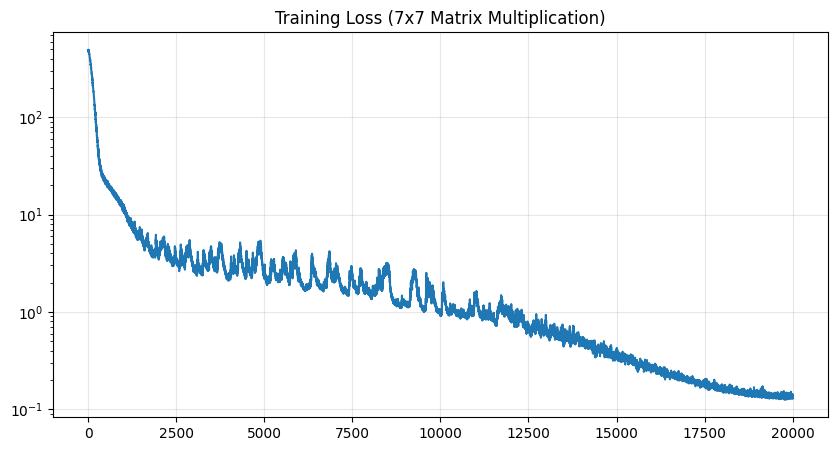

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)
for scale in [1, 2, 5, 10]:
    print(evaluate(model, n=N_SIZE, scale=scale))

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

## Modified version to test special cases

Training 7x7 MatrixNet:  10%|█         | 2023/20000 [00:13<02:40, 112.15it/s, loss=4.9674] 



==================== Step 2000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ -4.056  31.133]
 [-33.244  22.394]]
Prediction (first 2x2 corner):
 [[ -5.645  35.492]
 [-31.281  22.073]]
Full Matrix MAE: 1.477497



Training 7x7 MatrixNet:  20%|██        | 4024/20000 [00:24<01:26, 184.62it/s, loss=2.8703]



==================== Step 4000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[ 10.904 -18.519]
 [  8.841   0.772]]
Prediction (first 2x2 corner):
 [[  9.25  -14.721]
 [ 11.934  -0.369]]
Full Matrix MAE: 1.925775



Training 7x7 MatrixNet:  30%|███       | 6042/20000 [00:34<01:07, 206.30it/s, loss=1.9706]

...



==================== Step 16000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-31.889  34.867]
 [  2.539  11.926]]
Prediction (first 2x2 corner):
 [[-32.37   35.874]
 [  1.984  11.295]]
Full Matrix MAE: 0.444865



Training 7x7 MatrixNet:  90%|█████████ | 18035/20000 [01:36<00:10, 196.19it/s, loss=0.1589]



==================== Step 18000 | Test 7x7 ====================
Ground Truth (first 2x2 corner):
 [[-3.29   0.649]
 [44.725  8.83 ]]
Prediction (first 2x2 corner):
 [[-2.949  1.048]
 [44.224  8.822]]
Full Matrix MAE: 0.286344



Training 7x7 MatrixNet: 100%|██████████| 20000/20000 [01:47<00:00, 186.11it/s, loss=0.1354]



Special matrix identity tests
A @ I    | MAE = 1.052136e+00 | Rel = 4.571545e-01 | MaxErr = 2.915418e+00
I @ B    | MAE = 5.999317e-01 | Rel = 2.265441e-01 | MaxErr = 1.663812e+00
A @ 0    | MAE = 1.066239e+00 | Rel = 9.120539e+12 | MaxErr = 2.883099e+00
0 @ B    | MAE = 5.951201e-01 | Rel = 5.123354e+12 | MaxErr = 1.652368e+00
I @ I    | MAE = 1.102650e+00 | Rel = 3.812652e+00 | MaxErr = 3.115109e+00
0 @ 0    | MAE = 1.442277e+00 | Rel = 1.294920e+13 | MaxErr = 3.807299e+00
A @ B    | MAE = 3.515250e-01 | Rel = 1.967964e-02 | MaxErr = 1.127472e+00


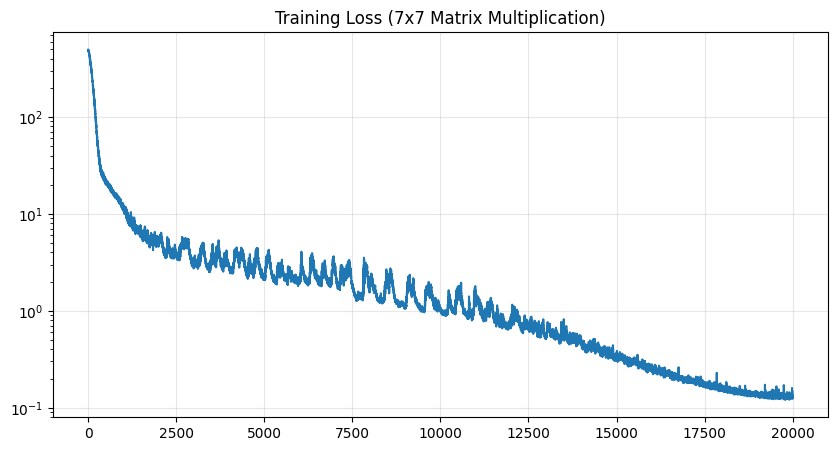

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

def evaluate_special_cases(model, n, scale=5.0):
    model.eval()

    with torch.no_grad():
        I = torch.eye(n, device=device).unsqueeze(0)
        Z = torch.zeros(1, n, n, device=device)

        A = (torch.rand(1, n, n, device=device) - 0.5) * 2 * scale
        B = (torch.rand(1, n, n, device=device) - 0.5) * 2 * scale

        cases = {
            "A @ I": (A, I, A),
            "I @ B": (I, B, B),
            "A @ 0": (A, Z, Z),
            "0 @ B": (Z, B, Z),
            "I @ I": (I, I, I),
            "0 @ 0": (Z, Z, Z),
            "A @ B": (A, B, torch.bmm(A, B)),
        }

        print("\nSpecial matrix identity tests")
        print("=" * 60)

        for name, (X, Y, target) in cases.items():
            pred = model(X, Y)
            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()
            rel = (
                torch.linalg.norm(err) /
                (torch.linalg.norm(target) + 1e-12)
            ).item()

            print(f"{name:8s} | MAE = {mae:.6e} | Rel = {rel:.6e} | MaxErr = {max_err:.6e}")

        print("=" * 60)

    model.train()

N_SIZE = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=20000)
evaluate_special_cases(model, N_SIZE, scale=5.0)

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()

## Modified version for ablation study

Training 5x5 MatrixNet:  20%|██        | 2021/10000 [00:15<02:34, 51.77it/s, loss=1.2349]  



==================== Step 2000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[ -3.601  24.808]
 [ -4.993 -10.869]]
Prediction (first 2x2 corner):
 [[-4.101 25.063]
 [-5.931 -9.868]]
Full Matrix MAE: 0.617708



Training 5x5 MatrixNet:  40%|████      | 4028/10000 [00:26<00:31, 186.85it/s, loss=1.2130]



==================== Step 4000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[14.164 -4.351]
 [35.408 24.191]]
Prediction (first 2x2 corner):
 [[14.831 -4.161]
 [34.358 24.565]]
Full Matrix MAE: 0.865084



Training 5x5 MatrixNet:  60%|██████    | 6025/10000 [00:36<00:21, 187.60it/s, loss=0.2879]



==================== Step 6000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[-14.896   2.726]
 [-37.222 -27.033]]
Prediction (first 2x2 corner):
 [[-14.159   3.421]
 [-37.229 -25.976]]
Full Matrix MAE: 0.596091



Training 5x5 MatrixNet:  80%|████████  | 8041/10000 [00:46<00:09, 201.47it/s, loss=0.1156]



==================== Step 8000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[  2.168 -12.992]
 [  8.054 -17.902]]
Prediction (first 2x2 corner):
 [[  2.408 -12.568]
 [  7.615 -17.848]]
Full Matrix MAE: 0.254804



Training 5x5 MatrixNet: 100%|██████████| 10000/10000 [00:56<00:00, 176.32it/s, loss=0.0319]


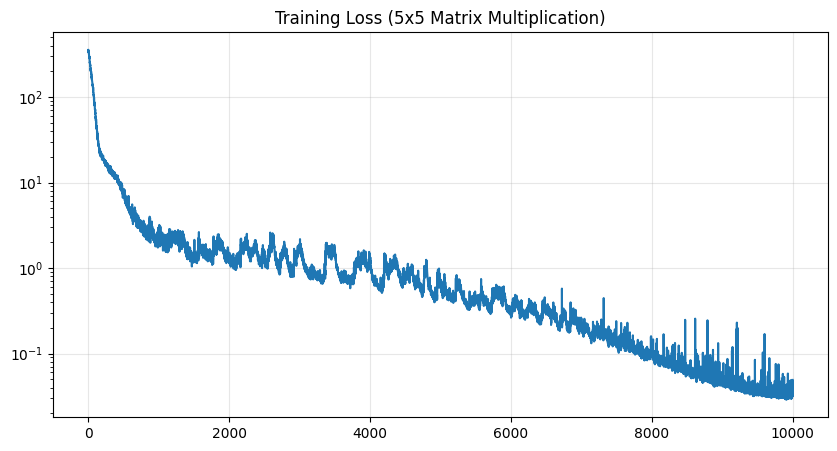

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

N_SIZE = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UniversalMatrixNet(n=N_SIZE, hidden_dim=512, n_layers=4).to(device)
model = torch.compile(model)

history = train(model, n=N_SIZE, total_steps=10000)

plt.figure(figsize=(10, 5))
plt.plot(history)
plt.yscale('log')
plt.title(f'Training Loss ({N_SIZE}x{N_SIZE} Matrix Multiplication)')
plt.grid(True, alpha=0.3)
plt.show()



Training model: Original_RMSNorm_Residual_SwiGLU


Training 5x5 MatrixNet:  20%|██        | 2018/10000 [00:13<01:27, 91.30it/s, loss=1.2188] 



==================== Step 2000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[ 14.445 -32.289]
 [  9.422 -16.021]]
Prediction (first 2x2 corner):
 [[ 17.48  -33.223]
 [  9.97  -16.88 ]]
Full Matrix MAE: 0.955924



Training 5x5 MatrixNet:  40%|████      | 4025/10000 [00:23<00:29, 205.14it/s, loss=0.9641]



==================== Step 4000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[16.699 -0.415]
 [19.532 18.914]]
Prediction (first 2x2 corner):
 [[15.967 -0.186]
 [19.259 17.429]]
Full Matrix MAE: 0.993431



...



==================== Step 6000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[-20.527  17.633]
 [ 20.215 -22.317]]
Prediction (first 2x2 corner):
 [[-20.914  18.136]
 [ 21.143 -22.942]]
Full Matrix MAE: 0.542306



Training 5x5 MatrixNet:  80%|████████  | 8018/10000 [00:43<00:10, 183.40it/s, loss=0.0341]



==================== Step 8000 | Test 5x5 ====================
Ground Truth (first 2x2 corner):
 [[17.789 22.755]
 [45.896 17.396]]
Prediction (first 2x2 corner):
 [[17.651 22.347]
 [45.986 17.528]]
Full Matrix MAE: 0.199557



Training 5x5 MatrixNet: 100%|██████████| 10000/10000 [00:54<00:00, 182.53it/s, loss=0.0059]



No_Residual
Final training loss: 6.193332e-02
Evaluation: {'scale': 5.0, 'mean_MAE': 0.06013016439974308, 'mean_relative_error': 0.004092138516716659, 'max_abs_error': 10.379730224609375}

 Original_RMSNorm_Residual_SwiGLU
Final loss: 0.035284724086523056
Eval: {'scale': 5.0, 'mean_MAE': 0.14236202016472815, 'mean_relative_error': 0.009796191705390811, 'max_abs_error': 14.391902923583984}

 MLP_instead_of_SwiGLU
Final loss: 0.09563695639371872
Eval: {'scale': 5.0, 'mean_MAE': 0.22940905764698982, 'mean_relative_error': 0.01575512792915106, 'max_abs_error': 5.998405456542969}

 No_RMSNorm
Final loss: 0.010932927019894123
Eval: {'scale': 5.0, 'mean_MAE': 0.0788556944578886, 'mean_relative_error': 0.00537736548576504, 'max_abs_error': 0.8106193542480469}

 No_Residual
Final loss: 0.06193332374095917
Eval: {'scale': 5.0, 'mean_MAE': 0.06013016439974308, 'mean_relative_error': 0.004092138516716659, 'max_abs_error': 10.379730224609375}


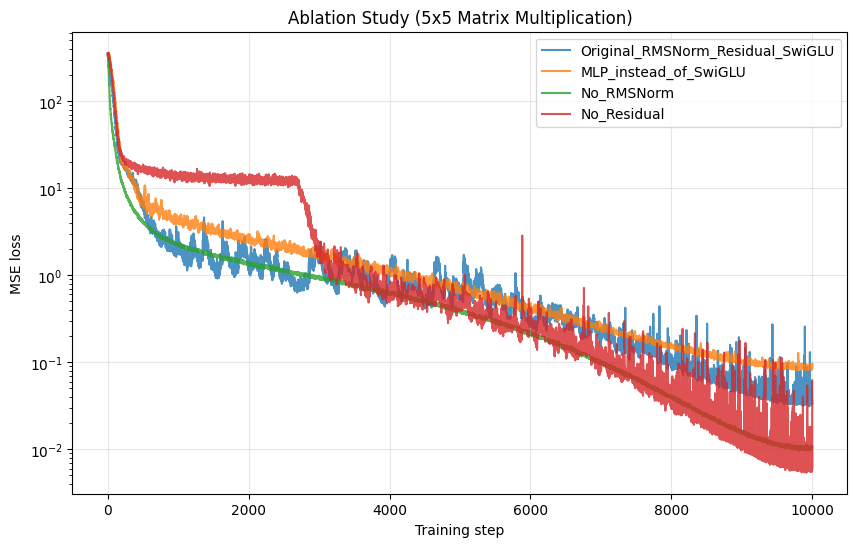

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    def forward(self, x):
        return self._norm(x.float()).type_as(x) * self.weight

class SwiGLUBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.w1 = nn.Linear(dim, intermediate_size, bias=False)
        self.w2 = nn.Linear(intermediate_size, dim, bias=False)
        self.w3 = nn.Linear(dim, intermediate_size, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class MLPBlock(nn.Module):
    def __init__(self, dim, intermediate_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, intermediate_size),
            nn.SiLU(),
            nn.Linear(intermediate_size, dim),
        )

    def forward(self, x):
        return self.net(x)

class UniversalMatrixNet(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=6):
        super().__init__()
        self.n = n
        input_dim = (n * n) * 2
        output_dim = n * n
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'norm': RMSNorm(hidden_dim),
                'ffn': SwiGLUBlock(hidden_dim, int(hidden_dim * 8/3))
            }) for _ in range(n_layers)
        ])
        
        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat([A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)], dim=1)
        x = self.embedding(x)
        
        for layer in self.layers:
            h = layer['norm'](x)
            x = x + layer['ffn'](h)
            
        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_MLP(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "norm": RMSNorm(hidden_dim),
                "ffn": MLPBlock(hidden_dim, hidden_dim * 4)
            }) for _ in range(n_layers)
        ])

        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for layer in self.layers:
            h = layer["norm"](x)
            x = x + layer["ffn"](h)

        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_NoNorm(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            SwiGLUBlock(hidden_dim, int(hidden_dim * 8 / 3))
            for _ in range(n_layers)
        ])

        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for ffn in self.layers:
            x = x + ffn(x)

        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

class MatrixNet_NoResidual(nn.Module):
    def __init__(self, n=3, hidden_dim=512, n_layers=4):
        super().__init__()
        self.n = n
        input_dim = 2 * n * n
        output_dim = n * n

        self.embedding = nn.Linear(input_dim, hidden_dim)

        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "norm": RMSNorm(hidden_dim),
                "ffn": SwiGLUBlock(hidden_dim, int(hidden_dim * 8 / 3))
            }) for _ in range(n_layers)
        ])

        self.final_norm = RMSNorm(hidden_dim)
        self.output_head = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, B):
        x = torch.cat(
            [A.view(-1, self.n * self.n), B.view(-1, self.n * self.n)],
            dim=1
        )

        x = self.embedding(x)

        for layer in self.layers:
            h = layer["norm"](x)
            x = layer["ffn"](h)   # no x + ...

        x = self.final_norm(x)
        out = self.output_head(x)
        return out.view(-1, self.n, self.n)

def run_test(model, step, n):
    model.eval()
    with torch.no_grad():
        test_A = (torch.rand(1, n, n, device=device) - 0.5) * 10
        test_B = (torch.rand(1, n, n, device=device) - 0.5) * 10
        
        ground_truth = torch.bmm(test_A, test_B)
        prediction = model(test_A, test_B)
        
        print(f"\n\n{'='*20} Step {step} | Test {n}x{n} {'='*20}")
        print(f"Ground Truth (first 2x2 corner):\n", ground_truth[0, :2, :2].cpu().numpy().round(3))
        print(f"Prediction (first 2x2 corner):\n", prediction[0, :2, :2].cpu().numpy().round(3))
        
        mae = torch.mean(torch.abs(prediction - ground_truth)).item()
        print(f"Full Matrix MAE: {mae:.6f}")
        print('='*60 + '\n')
    model.train()

def train(model, n, total_steps=20000, batch_size=512):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    criterion = nn.MSELoss()
    
    loss_history = []
    model.train()

    pbar = tqdm(range(total_steps), desc=f"Training {n}x{n} MatrixNet")
    for step in pbar:
        A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 10
        target = torch.bmm(A, B)

        optimizer.zero_grad()
        output = model(A, B)
        loss = criterion(output, target)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        loss_val = loss.item()
        loss_history.append(loss_val)

        if step % 100 == 0:
            pbar.set_postfix({"loss": f"{loss_val:.4f}"})

        if step > 0 and step % 2000 == 0:
            run_test(model, step, n)
            
    return loss_history

def evaluate(model, n, batch_size=4096, num_batches=20, scale=5.0):
    model.eval()

    mae_list = []
    rel_list = []
    max_err_list = []

    with torch.no_grad():
        for _ in range(num_batches):
            A = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale
            B = (torch.rand(batch_size, n, n, device=device) - 0.5) * 2 * scale

            target = torch.bmm(A, B)
            pred = model(A, B)

            err = pred - target

            mae = torch.mean(torch.abs(err)).item()
            max_err = torch.max(torch.abs(err)).item()

            rel = (
                torch.linalg.norm(err, dim=(1, 2)) /
                (torch.linalg.norm(target, dim=(1, 2)) + 1e-12)
            ).mean().item()

            mae_list.append(mae)
            rel_list.append(rel)
            max_err_list.append(max_err)

    model.train()

    return {
        "scale": scale,
        "mean_MAE": sum(mae_list) / len(mae_list),
        "mean_relative_error": sum(rel_list) / len(rel_list),
        "max_abs_error": max(max_err_list),
    }

N_SIZE = 5
TOTAL_STEPS = 10000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "Original_RMSNorm_Residual_SwiGLU": UniversalMatrixNet(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "MLP_instead_of_SwiGLU": MatrixNet_MLP(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "No_RMSNorm": MatrixNet_NoNorm(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
    "No_Residual": MatrixNet_NoResidual(
        n=N_SIZE, hidden_dim=512, n_layers=4
    ),
}

results = {}

for name, model in models.items():
    print(f"\n\nTraining model: {name}")
    print("=" * 80)

    model = model.to(device)

    # Optional. You can comment this out if torch.compile causes issues.
    model = torch.compile(model)

    history = train(model, n=N_SIZE, total_steps=TOTAL_STEPS)

    eval_result = evaluate(model, n=N_SIZE, scale=5.0)

    results[name] = {
        "final_loss": history[-1],
        "eval": eval_result,
        "history": history,
    }

    print(f"\n{name}")
    print(f"Final training loss: {history[-1]:.6e}")
    print(f"Evaluation: {eval_result}")


for name, r in results.items():
    print("\n", name)
    print("Final loss:", r["final_loss"])
    print("Eval:", r["eval"])

plt.figure(figsize=(10, 6))

for name, r in results.items():
    plt.plot(r["history"], label=name, alpha=0.8)

plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title(f"Ablation Study ({N_SIZE}x{N_SIZE} Matrix Multiplication)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()